# Unsupervised Learning on Graphs

This notebook explores a specific type of unsupervised representation learning technique with graph-structured data. In particular this will be a **contrastive learning** model, where an encoder is trained to be contrastive and distinguish between representations that are dependent on each other and those that are not.

A possible approach to obtain such an encoder is to train it to maximise the **local mutual information** between a global representation of the graph and its node representations. 

In [15]:
import torch
import torch.nn as nn
import torch_geometric.nn as pygnn
import torch.nn.functional as F
from typing import Literal 
import io

For our encoder we will use a polynomial filter introduced by Defferrard et. al. 

$$
\begin{aligned}
H &= \sum_{k=1}^{K}Z^{(k)}\Theta^{(k)} \\ 
Z^{(1)} & = X \\
Z^{(2)} & = \tilde{L}X \\
Z^{(k)} & = 2\tilde{L}Z^{(k-1)} - Z^{(k-2)}
\end{aligned}
$$
where $\tilde{L}=2L/\lambda_{\text{max}} - I$ is a Laplacian matrix scaled by its largest eigenvalue. Because this architecture uses Chebyshev polynomials, it is commonly known as *ChebNet*. PyG already provides an implementation of the base convolution for us. 

Hyperparameter $K$ is the order of the polynomial and directly controls the receptive field of the filter. 

In [16]:
class ChebNet(nn.Module):

    def __init__(self, in_channels, hidden_channels, out_channels, **kwargs):
        super().__init__(**kwargs)


        self.encoder = nn.Sequential(
            nn.Linear(in_features=in_channels,out_features=hidden_channels),
            nn.PReLU()
        )

        self.convs = pygnn.ChebConv(in_channels=hidden_channels, out_channels=hidden_channels, K=5)

        self.decoder = nn.Sequential(
            torch.nn.BatchNorm1d(hidden_channels, momentum=0.01),
            nn.Linear(in_features=hidden_channels,out_features=out_channels),
            nn.PReLU(),
        )

        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x, edge_index):
        x = self.encoder(x)
        x = self.dropout(x)
        x = self.convs(x, edge_index)
        x = self.decoder(x)

        return x
    
    def get_negative_example(self, x):
        # Shuffles along the node dimension (node i gets features of j)
        n = x.shape[-2]
        perm = torch.randperm(n)
        x_ = x.clone()
        return x_[perm]

In [17]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

embeddings = Planetoid(root=f'data/', name='cora', transform=NormalizeFeatures())

In [18]:
graph = embeddings[0]

In [105]:
model = ChebNet(in_channels=1433, hidden_channels=512, out_channels=512)

In [106]:
class Discriminator(nn.Module):
    def __init__(self, dim):
        super(Discriminator, self).__init__()
        self.fn = nn.Bilinear(dim, dim, 1)

    def forward(self, h, c):
        c_x = c.expand_as(h).contiguous()
        sc = self.fn(h, c_x).squeeze(1)
        return sc

In [107]:
disc = Discriminator(dim=512)

In [108]:
def get_graph_summary(x):
    return x.mean(dim=-2)

In [109]:
def contrastive_loss(H, H_tilde, s, D: Discriminator):
    embeddings = torch.cat((H, H_tilde), dim=0)
    return F.binary_cross_entropy_with_logits(
        D(embeddings, s),
        torch.cat((torch.ones(H.shape[0], device=s.device), 
                   torch.zeros(H.shape[0], device=s.device)))
    )

In [110]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
disc = disc.to(device)
graph = graph.to(device)

In [111]:
optim = torch.optim.Adam([{'params': model.parameters(), 'lr': 0.0005},
                          {'params': disc.parameters(), 'lr': 0.001}])

In [112]:
epochs = 750
losses = []
for e in range(epochs):
    model.train()
    disc.train()
    optim.zero_grad()

    h = model(graph.x, graph.edge_index)
    h_tilde = model(model.get_negative_example(graph.x), graph.edge_index)

    s = get_graph_summary(h)

    loss = contrastive_loss(H=h, H_tilde=h_tilde, s=s, D=disc)

    loss.backward()
    optim.step()
    if e %50 == 0:
        print(e, loss.item())
    losses.append(loss.item())

0 0.7904731631278992
50 0.6842472553253174
100 0.13364365696907043
150 0.009179899469017982
200 0.0026214788667857647
250 0.0008692348492331803
300 0.0006605763337574899
350 0.0004914863966405392
400 0.00020778844191227108
450 0.0001829631073633209
500 0.00022360043658409268
550 8.890676690498367e-05
600 9.393554501002654e-05
650 0.00029273040127009153
700 8.253158739535138e-05


In [113]:
embeddings = model(graph.x, graph.edge_index).detach()
train_embs = embeddings[graph.train_mask]
train_labels = graph.y[graph.train_mask]

val_embs = embeddings[graph.val_mask]
val_labels = graph.y[graph.val_mask]

In [114]:
import matplotlib.pyplot as plt

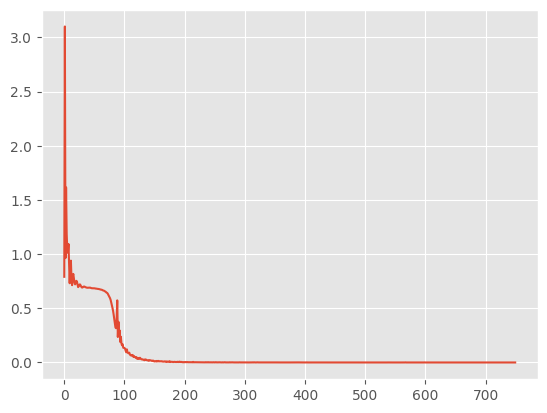

In [115]:
plt.plot(losses)

# Supervised Validation

We can now use the embeddings obtained with the unsupervised approach and apply a **linear** classifier on them. 

In [128]:
class LinearClassifier(nn.Module):
    def __init__(self, features, classes):
        super().__init__()
        self.lin = nn.Linear(features, classes)


    def forward(self, x):
        return self.lin(x)
    

class EarlyStopper():
    def __init__(self, patience, mode: Literal['max', 'min']='max'):
        self.patience = patience
        self.mode = mode
        self.best = float('-inf') if mode == 'max'else float('inf')
        self.weights_buffer = io.BytesIO()
        self.best_iter = -1
        self.global_iter = 0
        self.count = 0

        # buffer.seek(0)   # Rewind to the start of the buffer
        # buffer.truncate(0)  # Clear the buffer contents
        # torch.save(new_model.state_dict(), buffer)
        # buffer.seek(0)  # Rewind to the start again, ready for reading

    def _is_better(self, new_value):
        if self.mode == 'max':
            return new_value > self.best 
        return new_value < self.best 

    def __call__(self, new_value, model):
        
        if self._is_better(new_value):
            self.best = new_value
            self.best_iter = self.global_iter
            self.count = 0
            self.weights_buffer.seek(0)
            self.weights_buffer.truncate(0)
            torch.save(model.state_dict(), self.weights_buffer)
        else:
            self.count += 1
        self.global_iter += 1
        
        if self.count > self.patience:
            return True
        return False
        
    def set_best_weights(self, model):
        self.weights_buffer.seek(0)
        model.load_state_dict(torch.load(self.weights_buffer))



In [129]:
def accuracy(X, y, model):
    return (torch.argmax(torch.nn.functional.softmax(model(X), dim=-1),dim=-1) == y).to(torch.float32).mean().cpu().numpy()

In [159]:

    
classifier = LinearClassifier(512,7)
classifier = classifier.to(device)

early_stopping = EarlyStopper(patience=20, mode='max')

In [160]:
opt = torch.optim.Adam(classifier.parameters(), lr=0.005)
loss_fn = nn.CrossEntropyLoss()

In [161]:
classifier_train_loss = []
classifier_val_loss = [] 

classifier_train_acc = []
classifier_val_acc = [] 

for epoch in range(100):
    classifier.train()
    opt.zero_grad()

    logits = classifier(train_embs)

    loss = loss_fn(logits, train_labels)
    loss.backward()
    opt.step()

    classifier_train_loss.append(loss.item())
    classifier_train_acc.append(accuracy(X=train_embs, y=train_labels, model=classifier))
    # eval 
    with torch.no_grad():
        classifier.eval()

        logits = classifier(val_embs)
        val_loss = loss_fn(logits, val_labels)
        classifier_val_loss.append(val_loss.item())
        classifier_val_acc.append(accuracy(X=val_embs, y=val_labels, model=classifier))

        if early_stopping(new_value=classifier_val_acc[-1], model=classifier):
            early_stopping.set_best_weights(model=classifier)
            print(f'Early stopped at {epoch}')
            
            break



    # print(loss.item())

Early stopped at 33


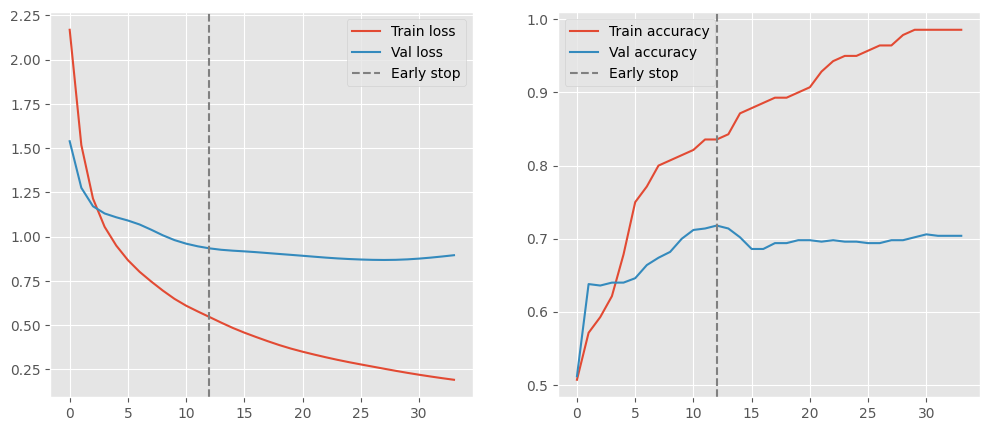

In [165]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))
ax[0].plot(classifier_train_loss, label='Train loss')
ax[0].plot(classifier_val_loss, label='Val loss')
ax[1].plot(classifier_train_acc, label='Train accuracy')
ax[1].plot(classifier_val_acc, label='Val accuracy')
ax[0].axvline(x=early_stopping.best_iter, color='r', linestyle='--', label=f'Early stop', c='grey')
ax[1].axvline(x=early_stopping.best_iter, color='r', linestyle='--', label=f'Early stop', c='grey')
ax[0].legend()
ax[1].legend()

In [166]:
print(f'Best: {early_stopping.best}')

Best: 0.718000054359436


In [122]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch

embeddings = model(graph.x, graph.edge_index).cpu().detach().numpy()
labels = graph.y.cpu().detach().numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=30, early_exaggeration=12, n_iter=2000)
data_2d = tsne.fit_transform(embeddings)


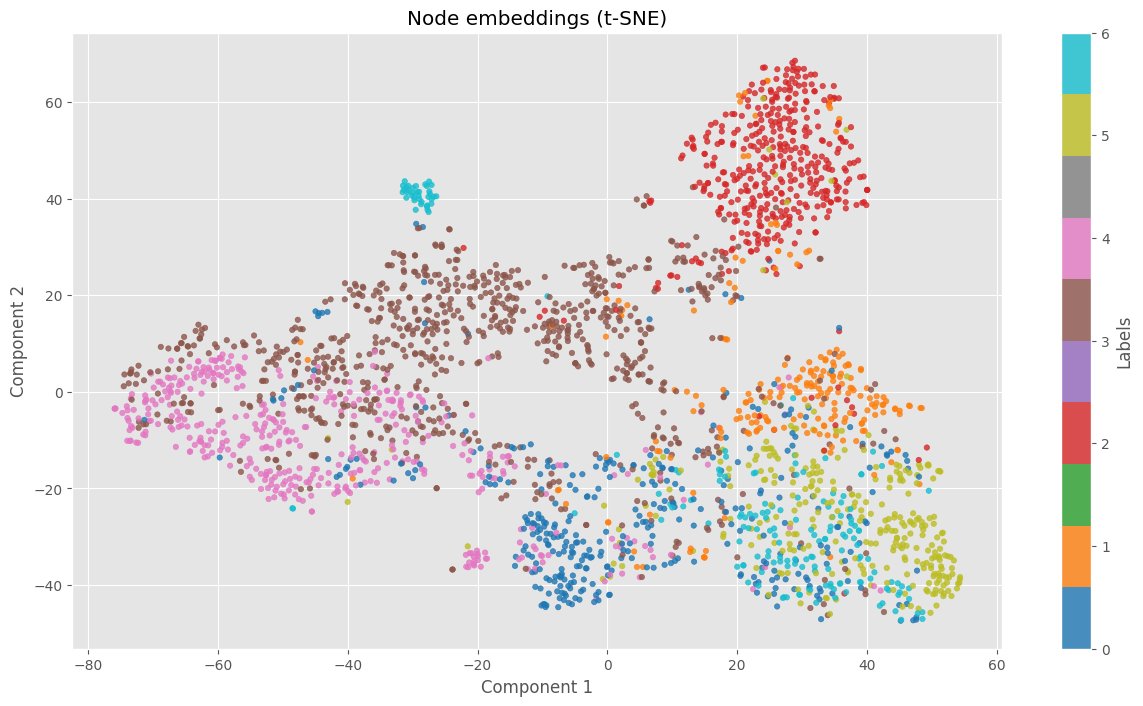

In [123]:
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(15, 8))
scatter = plt.scatter(data_2d[:, 0], data_2d[:, 1], c=labels, cmap='tab10', s=15, alpha=0.8)
plt.colorbar(scatter, label="Labels")
plt.title("Node embeddings (t-SNE)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()
